# 미니프로젝트: 결측치·이상치·클래스 불균형 처리 (Vibe Coding)

#### <목표>
오늘 배운 **결측치/이상치 처리, Under/Oversampling, SVDD**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Telco Customer Churn (통신사 고객 이탈 데이터)
- 고객의 인적사항, 가입 서비스, 요금·계약 정보와 이탈(Churn) 여부를 담은 데이터

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 고객 정보로 이탈 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day4_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

**[과제]** 써니는 통신사 고객 이탈 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 호출하고 데이터를 불러와 구조를 확인하는 코드를 AI와 상의해서 작성하세요.

In [1]:
# ===== 기본 라이브러리 =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# 한글 그래프 깨짐 방지 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ===== scikit-learn =====
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.manifold import TSNE
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# ===== 클래스 불균형 처리 =====
from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek

# ===== 분류 모델 =====
from xgboost import XGBClassifier

In [5]:
# 데이터 불러오기
df = pd.read_csv("dataset/day4_miniproject.csv")

# 원본 보존용 복사본 (전처리 과정에서 사용)
df_raw = df.copy()
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1) 데이터 탐색 (EDA)

### 1-1) 기본 EDA 진행

**[과제]** 써니는 데이터 분석 전, 데이터의 구조적 및 통계적 정보가 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [7]:
# 기본 구조 확인
print("데이터 크기:", df.shape)

print("\n컬럼 목록:")
print(df.columns.tolist())

데이터 크기: (7043, 20)

컬럼 목록:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [8]:
print("\n데이터 타입:")
print(df.dtypes.to_string())   # Series를 문자열로 출력


데이터 타입:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure              float64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object


In [10]:
print("\n결측치 개수:")
print(df.isnull().sum().to_string())

print("\n타겟 변수(Churn) 분포:")
print(df["Churn"].value_counts().to_string())


결측치 개수:
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure              211
PhoneService          0
MultipleLines         0
InternetService     140
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod       211
MonthlyCharges      211
TotalCharges         11
Churn                 0

타겟 변수(Churn) 분포:
Churn
No     5174
Yes    1869


In [13]:
# 결측치가 있는 행만 보기
df[df.isnull().any(axis=1)].head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
25,Female,0,No,No,30.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,NaN,55.30,1530.60,No
37,Female,0,No,No,46.0,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),NaN,3548.30,No
44,Female,0,Yes,No,13.0,Yes,Yes,DSL,Yes,Yes,No,Yes,Yes,No,Month-to-month,Yes,NaN,76.20,981.45,No
50,Female,1,No,No,43.0,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,NaN,3838.75,No
56,Female,0,Yes,Yes,63.0,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,One year,Yes,NaN,99.65,6311.20,No


In [14]:
# 컬럼별 결측 비율
(df.isnull().sum() / len(df) * 100).round(2)

gender              0.00
SeniorCitizen       0.00
Partner             0.00
Dependents          0.00
tenure              3.00
PhoneService        0.00
MultipleLines       0.00
InternetService     1.99
OnlineSecurity      0.00
OnlineBackup        0.00
DeviceProtection    0.00
TechSupport         0.00
StreamingTV         0.00
StreamingMovies     0.00
Contract            0.00
PaperlessBilling    0.00
PaymentMethod       3.00
MonthlyCharges      3.00
TotalCharges        0.16
Churn               0.00
dtype: float64

In [15]:
# 여러 컬럼이 동시에 결측인지
missing_cols = ["tenure", "PaymentMethod", "MonthlyCharges", "InternetService", "TotalCharges"]
df[missing_cols].isnull().sum()

tenure             211
PaymentMethod      211
MonthlyCharges     211
InternetService    140
TotalCharges        11
dtype: int64

**[과제]** 써니는 EDA를 통해 전처리가 필요한 부분을 발견했습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

> Tip: 'Churn' 변수의 타입이나 값 표기 방식

Churn 비율(%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64



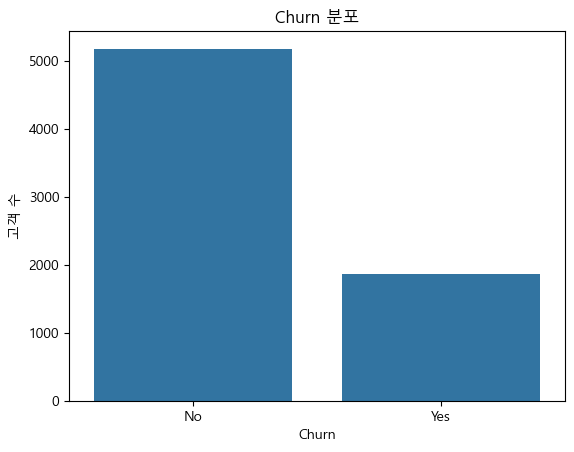

### 1-2) 결측치 현황 파악

**[과제]** 써니는 데이터에 결측치가 존재하는지, 존재한다면 어떤 형태로 얼마나 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [22]:
# ============================================================
# 1-2) 결측치 존재 여부 확인
# ============================================================

# 1) 컬럼별 결측치 개수
missing_count = df.isnull().sum()
missing_ratio = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "결측 개수": missing_count,
    "결측 비율(%)": missing_ratio
})
missing_df = missing_df[missing_df["결측 개수"] > 0].sort_values("결측 개수", ascending=False)

print("=== 결측치가 있는 컬럼 ===")
print(missing_df.to_string())

print(f"\n전체 행 수: {len(df)}")
print(f"결측치가 1개라도 있는 행 수: {df.isnull().any(axis=1).sum()}")
print(f"완전한 행(결측 0개): {df.notnull().all(axis=1).sum()}")

=== 결측치가 있는 컬럼 ===
                 결측 개수  결측 비율(%)
tenure             211      3.00
PaymentMethod      211      3.00
MonthlyCharges     211      3.00
InternetService    140      1.99
TotalCharges        11      0.16

전체 행 수: 7043
결측치가 1개라도 있는 행 수: 763
완전한 행(결측 0개): 6280


In [23]:
# ============================================================
# 2) 결측치가 어떤 형태로 존재하는지 확인
# ============================================================

# 결측이 발생한 주요 컬럼
miss_cols = ["tenure", "InternetService", "PaymentMethod", "MonthlyCharges", "TotalCharges"]

# 결측 패턴 라벨 만들기 (어떤 컬럼이 비었는지)
def get_missing_pattern(row):
    cols = [c for c in miss_cols if pd.isnull(row[c])]
    return "없음" if len(cols) == 0 else " + ".join(cols)

df["missing_pattern"] = df[miss_cols].apply(get_missing_pattern, axis=1)

print("=== 결측 패턴별 행 수 ===")
print(df["missing_pattern"].value_counts().to_string())

print(f"\n=== 2개 이상 컬럼이 동시에 결측인 행: {(df[miss_cols].isnull().sum(axis=1) >= 2).sum()}개 ===")

=== 결측 패턴별 행 수 ===
missing_pattern
없음                                  6280
PaymentMethod                        201
MonthlyCharges                       201
tenure                               198
InternetService                      131
TotalCharges                          11
tenure + PaymentMethod                 7
InternetService + MonthlyCharges       5
tenure + InternetService               3
tenure + MonthlyCharges                3
PaymentMethod + MonthlyCharges         2
InternetService + PaymentMethod        1

=== 2개 이상 컬럼이 동시에 결측인 행: 21개 ===


In [24]:
# ============================================================
# 3) 결측 행 샘플 확인
# ============================================================

print("=== 결측이 있는 행 샘플 ===")
display(df[df[miss_cols].isnull().any(axis=1)][miss_cols + ["Churn"]].head(10))

=== 결측이 있는 행 샘플 ===


,tenure,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,Churn
25,30.0,DSL,NaN,55.30,1530.60,No
37,46.0,Fiber optic,Credit card (automatic),NaN,3548.30,No
44,13.0,DSL,NaN,76.20,981.45,No
50,43.0,Fiber optic,Electronic check,NaN,3838.75,No
56,63.0,Fiber optic,NaN,99.65,6311.20,No
66,47.0,NaN,Electronic check,78.90,3650.35,No
74,3.0,NaN,Bank transfer (automatic),64.50,177.40,No
79,45.0,No,Credit card (automatic),NaN,1216.60,No
96,71.0,NaN,Credit card (automatic),66.85,4748.70,No
101,1.0,No,Electronic check,NaN,19.45,No


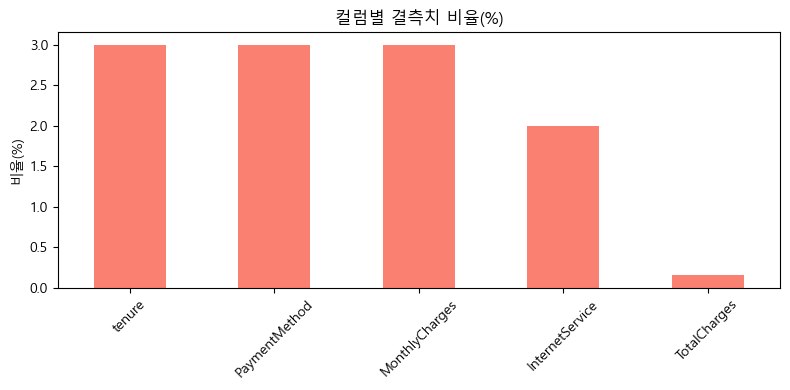

In [26]:
# ============================================================
# 4) 시각화
# ============================================================

# 컬럼별 결측치 막대그래프
plt.figure(figsize=(8, 4))
missing_df["결측 비율(%)"].plot(kind="bar", color="salmon")
plt.title("컬럼별 결측치 비율(%)")
plt.ylabel("비율(%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 1-3) 클래스 불균형 확인

**[과제]** 써니는 Churn 비율이 얼마나 불균형한지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

Churn 비율(%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64



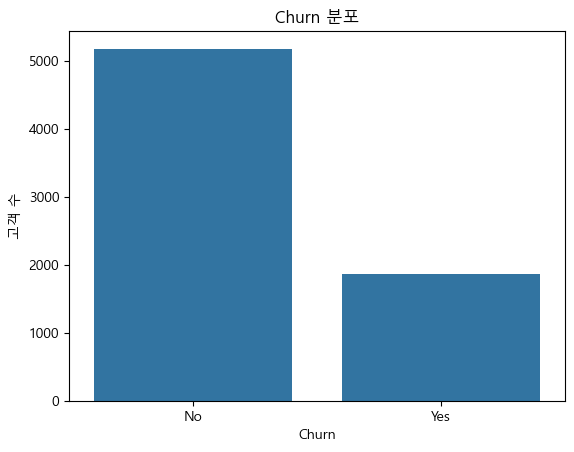

In [21]:
print("Churn 비율(%):")
print(df["Churn"].value_counts(normalize=True).mul(100).round(2))
print()

sns.countplot(data=df, x="Churn", order=["No", "Yes"])
plt.title("Churn 분포")
plt.ylabel("고객 수")
plt.show()

### 1-4) 이상치 후보 탐색

**[과제]** 써니는 수치형 변수에 이상치가 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [27]:
# 이상치 탐색 대상 수치형 컬럼
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

print("=== 기술통계량 ===")
print(df[num_cols].describe().round(2).to_string())

def check_outliers_iqr(series, col_name):
    """IQR 방식으로 이상치 개수와 경계값 반환"""
    s = series.dropna()  # 결측치 제외 후 계산
    
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = s[(s < lower) | (s > upper)]
    
    return {
        "컬럼": col_name,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "하한": round(lower, 2),
        "상한": round(upper, 2),
        "이상치 개수": len(outliers),
        "이상치 비율(%)": round(len(outliers) / len(s) * 100, 2)
    }

# 컬럼별 이상치 요약표
outlier_summary = pd.DataFrame([check_outliers_iqr(df[col], col) for col in num_cols])
print("=== IQR 기반 이상치 요약 ===")
print(outlier_summary.to_string(index=False))

=== 기술통계량 ===
        tenure  MonthlyCharges  TotalCharges
count  6832.00         6832.00       7032.00
mean     32.38           64.76       2283.30
std      24.57           30.08       2266.77
min       0.00           18.25         18.80
25%       9.00           35.59        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.85       3794.74
max      72.00          118.75       8684.80
=== IQR 기반 이상치 요약 ===
            컬럼     Q1      Q3     IQR       하한      상한  이상치 개수  이상치 비율(%)
        tenure   9.00   55.00   46.00   -60.00  124.00       0        0.0
MonthlyCharges  35.59   89.85   54.26   -45.81  171.24       0        0.0
  TotalCharges 401.45 3794.74 3393.29 -4688.48 8884.67       0        0.0


In [28]:
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    outlier_mask = (df[col] < lower) | (df[col] > upper)
    outlier_df = df.loc[outlier_mask, [col, "Churn"]]
    
    print(f"\n{'='*50}")
    print(f"[{col}] 이상치 {outlier_mask.sum()}개")
    print(f"범위: {lower:.2f} ~ {upper:.2f}")
    print(f"이상치 값 샘플:")
    print(outlier_df[col].describe().round(2).to_string())
    print(f"\n이상치 중 Churn 분포:")
    print(outlier_df["Churn"].value_counts().to_string())


[tenure] 이상치 0개
범위: -60.00 ~ 124.00
이상치 값 샘플:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN

이상치 중 Churn 분포:
Series([], )

[MonthlyCharges] 이상치 0개
범위: -45.81 ~ 171.24
이상치 값 샘플:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN

이상치 중 Churn 분포:
Series([], )

[TotalCharges] 이상치 0개
범위: -4688.48 ~ 8884.67
이상치 값 샘플:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN

이상치 중 Churn 분포:
Series([], )


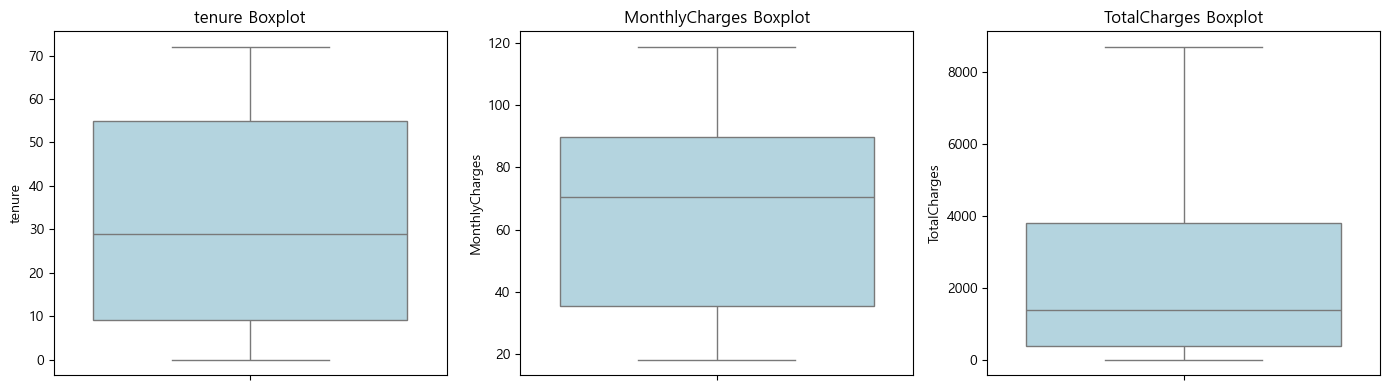

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color="lightblue")
    axes[i].set_title(f"{col} Boxplot")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

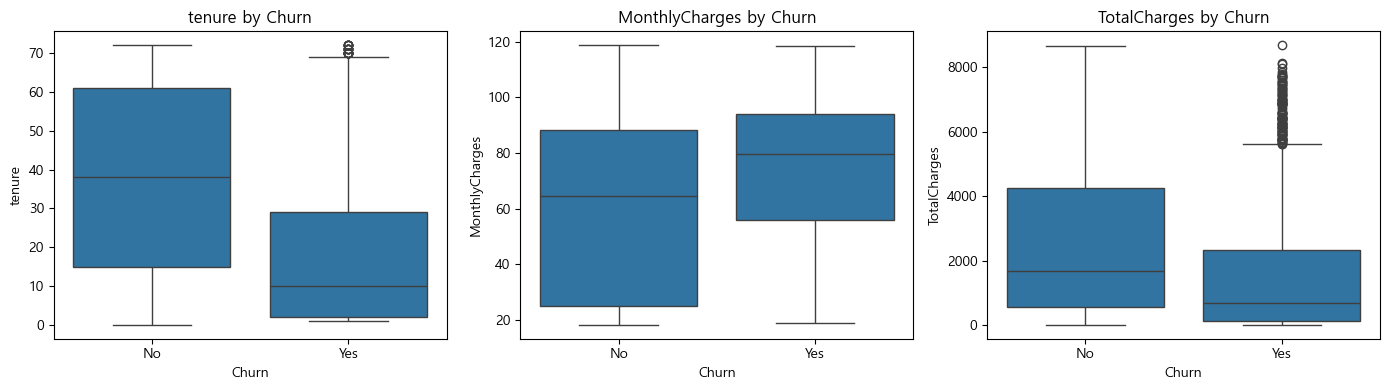

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Churn")

plt.tight_layout()
plt.show()

## 2) 결측치 처리

**[과제]** 써니는 데이터셋에 존재하는 결측치를 제거하거나 대치하려 합니다.

이때 변수마다 분포나 특성이 다르면 적합한 대치법도 달라질 수 있다고 생각합니다.

AI와 상의하여 변수별로 제거와 대치 중 어떤 방법이 적합한지 결정하고, 대치를 선택했다면 값 기반, 통계 기반(평균/중앙값/최빈값), 머신러닝 기반(KNN Imputer) 중 어떤 방식이 적합한지 정하여 적용해보세요.

In [31]:
# ============================================================
# 2) 결측치 처리 — 변수별 제거/대치 판단
# ============================================================

df_miss = df.copy()  # 원본 보존: df_raw 사용해도 됨

miss_cols = ["tenure", "InternetService", "PaymentMethod", "MonthlyCharges", "TotalCharges"]

def recommend_missing_strategy(data, col, target="Churn"):
    """컬럼별 결측 비율·타입·왜도 기반으로 제거/대치 추천"""
    n_miss = data[col].isnull().sum()
    miss_ratio = n_miss / len(data) * 100
    
    # 제거 시 남는 행 수
    n_after_drop = len(data) - n_miss
    
    # 결측 행의 Churn=Yes 비율
    churn_yes_ratio = np.nan
    if n_miss > 0:
        churn_yes_ratio = (data.loc[data[col].isnull(), target] == "Yes").mean() * 100
    
    # 변수 유형
    is_numeric = pd.api.types.is_numeric_dtype(data[col])
    
    # 왜도 (수치형만)
    skew = data[col].dropna().skew() if is_numeric and n_miss < len(data) else np.nan
    
    # 판단 규칙
    if miss_ratio == 0:
        strategy = "해당 없음"
        method = "-"
    elif miss_ratio >= 10:
        strategy = "제거 검토"
        method = "drop 또는 대치 병행 검토"
    elif miss_ratio >= 5:
        strategy = "대치 권장 (비율 다소 높음)"
        method = "최빈값(범주) / 중앙값·KNN(수치)"
    else:
        strategy = "대치 권장"
        if is_numeric:
            if abs(skew) > 1:
                method = "중앙값 (왜도 큼)"
            elif col == "TotalCharges":
                method = "값 기반 (tenure × MonthlyCharges)"
            elif col in ["tenure", "MonthlyCharges"]:
                method = "KNN Imputer 또는 중앙값"
            else:
                method = "중앙값"
        else:
            method = "최빈값"
    
    return {
        "변수": col,
        "결측 수": n_miss,
        "결측 비율(%)": round(miss_ratio, 2),
        "제거 시 남는 행": n_after_drop,
        "결측행 Churn=Yes(%)": round(churn_yes_ratio, 2) if n_miss > 0 else 0,
        "왜도": round(skew, 2) if not np.isnan(skew) else "-",
        "추천": strategy,
        "추천 대치법": method,
    }

# 컬럼별 판단표
decision_df = pd.DataFrame([recommend_missing_strategy(df_miss, col) for col in miss_cols])
print("=== 변수별 제거/대치 판단 ===")
print(decision_df.to_string(index=False))

# 전체 행 제거 시 영향
n_drop_all = df_miss[miss_cols].isnull().any(axis=1).sum()
print(f"\n5개 컬럼 중 하나라도 결측인 행: {n_drop_all}개")
print(f"전체 제거 시 남는 행: {len(df_miss) - n_drop_all}개 ({(len(df_miss)-n_drop_all)/len(df_miss)*100:.1f}%)")
print("→ 결측이 여러 컬럼에 흩어져 있어 행 제거는 비효율적 → 컬럼별 대치 권장")

=== 변수별 제거/대치 판단 ===
             변수  결측 수  결측 비율(%)  제거 시 남는 행  결측행 Churn=Yes(%)    왜도    추천                         추천 대치법
         tenure   211      3.00       6832             27.96  0.24 대치 권장             KNN Imputer 또는 중앙값
InternetService   140      1.99       6903             30.00     - 대치 권장                            최빈값
  PaymentMethod   211      3.00       6832             25.12     - 대치 권장                            최빈값
 MonthlyCharges   211      3.00       6832             27.49 -0.22 대치 권장             KNN Imputer 또는 중앙값
   TotalCharges    11      0.16       7032              0.00  0.96 대치 권장 값 기반 (tenure × MonthlyCharges)

5개 컬럼 중 하나라도 결측인 행: 763개
전체 제거 시 남는 행: 6280개 (89.2%)
→ 결측이 여러 컬럼에 흩어져 있어 행 제거는 비효율적 → 컬럼별 대치 권장


In [32]:
# ============================================================
# 2) 결측치 대치 실행
# ============================================================

df_clean = df_miss.copy()

# --- Step 1) 범주형: 최빈값 대치 ---
cat_cols = ["InternetService", "PaymentMethod"]

for col in cat_cols:
    mode_val = df_clean[col].mode()[0]
    n_before = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"[{col}] 최빈값 '{mode_val}' 대치 → {n_before}개 처리")

# --- Step 2) tenure: 중앙값 대치 ---
tenure_median = df_clean["tenure"].median()
n_before = df_clean["tenure"].isnull().sum()
df_clean["tenure"] = df_clean["tenure"].fillna(tenure_median)
print(f"[tenure] 중앙값 {tenure_median} 대치 → {n_before}개 처리")

# --- Step 3) MonthlyCharges: KNN Imputer ---
from sklearn.impute import KNNImputer

# KNN에 사용할 수치형 컬럼 (결측 없는 SeniorCitizen 포함)
knn_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

imputer = KNNImputer(n_neighbors=5)
df_clean[knn_cols] = imputer.fit_transform(df_clean[knn_cols])
n_mc_filled = df_miss["MonthlyCharges"].isnull().sum()
print(f"[MonthlyCharges] KNN Imputer(k=5) 대치 → {n_mc_filled}개 처리")

# --- Step 4) TotalCharges: 값 기반 대치 ---
def fill_total_charges(row):
    if pd.notnull(row["TotalCharges"]):
        return row["TotalCharges"]
    # tenure=0 신규 고객: 첫 달 요금 ≈ MonthlyCharges
    if row["tenure"] == 0:
        return row["MonthlyCharges"]
    # 그 외: 가입개월 × 월요금
    return row["tenure"] * row["MonthlyCharges"]

n_before = df_clean["TotalCharges"].isnull().sum()
df_clean["TotalCharges"] = df_clean.apply(fill_total_charges, axis=1)
print(f"[TotalCharges] 값 기반 대치 → {n_before}개 처리")

# --- 결과 확인 ---
print("\n=== 대치 후 결측치 확인 ===")
print(df_clean.isnull().sum().to_string())
print(f"\n대치 전 shape: {df_miss.shape}")
print(f"대치 후 shape: {df_clean.shape}")
print(f"행 수 변화: 없음 (대치만 수행)")

[InternetService] 최빈값 'Fiber optic' 대치 → 140개 처리
[PaymentMethod] 최빈값 'Electronic check' 대치 → 211개 처리
[tenure] 중앙값 29.0 대치 → 211개 처리
[MonthlyCharges] KNN Imputer(k=5) 대치 → 211개 처리
[TotalCharges] 값 기반 대치 → 0개 처리

=== 대치 후 결측치 확인 ===
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
missing_pattern     0

대치 전 shape: (7043, 21)
대치 후 shape: (7043, 21)
행 수 변화: 없음 (대치만 수행)


## 3) 이상치 처리

**[과제]** 써니는 데이터셋에 존재하는 이상치를 제거하고자 합니다.

다만 이탈(Churn) 고객이 실제로는 "정상 범위를 벗어난" 요금 및 이용 패턴을 가진 고객일 수 있다는 점이 마음에 걸립니다. 이상치 제거가 소수 클래스(Churn)를 함께 지워버릴 위험은 없는지 AI와 상의하여 검토하고 안전한 처리 기준을 정해 적용해 보세요.

In [33]:
# ============================================================
# 3) 이상치 제거가 소수 클래스(Churn=Yes)에 미치는 영향 평가
# ============================================================
# 전제: df_clean = 2장 결측치 대치 완료 데이터

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

def get_iqr_bounds(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

def evaluate_outlier_removal_risk(data, cols, target="Churn", pos_label="Yes"):
    base_yes_rate = (data[target] == pos_label).mean()
    total_yes = (data[target] == pos_label).sum()
    results = []

    outlier_masks = {}

    for col in cols:
        lower, upper = get_iqr_bounds(data[col])
        mask = (data[col] < lower) | (data[col] > upper)
        outlier_masks[col] = mask

        removed = data[mask]
        n_remove = mask.sum()
        yes_in_removed = (removed[target] == pos_label).sum()
        yes_rate_removed = yes_in_removed / n_remove if n_remove > 0 else 0
        yes_loss_pct = yes_in_removed / total_yes * 100 if total_yes > 0 else 0

        # 위험도: 이상치 내 Yes 비율이 전체보다 높거나, 전체 Yes의 5% 이상이 사라지면 '높음'
        if n_remove == 0:
            risk = "없음 (이상치 0건)"
        elif yes_rate_removed > base_yes_rate * 1.1 or yes_loss_pct >= 5:
            risk = "높음"
        elif yes_rate_removed >= base_yes_rate * 0.9:
            risk = "중간"
        else:
            risk = "낮음"

        results.append({
            "변수": col,
            "하한": round(lower, 2),
            "상한": round(upper, 2),
            "이상치 수": n_remove,
            "이상치 내 Yes 수": yes_in_removed,
            "이상치 내 Yes 비율(%)": round(yes_rate_removed * 100, 2),
            "전체 Yes 대비 손실(%)": round(yes_loss_pct, 2),
            "제거 위험도": risk,
        })

    # 여러 컬럼 중 하나라도 이상치면 제거하는 경우
    any_mask = pd.DataFrame(outlier_masks).any(axis=1)
    removed_all = data[any_mask]
    yes_lost_all = (removed_all[target] == pos_label).sum()

    summary = {
        "전체 Yes 비율(%)": round(base_yes_rate * 100, 2),
        "전체 Yes 수": total_yes,
        "통합 제거 행 수": any_mask.sum(),
        "통합 제거 시 Yes 손실": yes_lost_all,
        "통합 제거 시 Yes 보존율(%)": round((total_yes - yes_lost_all) / total_yes * 100, 2),
    }

    return pd.DataFrame(results), summary, any_mask

risk_df, risk_summary, outlier_any_mask = evaluate_outlier_removal_risk(df_clean, num_cols)

print("=== 컬럼별 이상치 제거 위험 평가 ===")
print(risk_df.to_string(index=False))

print("\n=== 통합 제거 시 영향 ===")
for k, v in risk_summary.items():
    print(f"{k}: {v}")

=== 컬럼별 이상치 제거 위험 평가 ===
            변수       하한      상한  이상치 수  이상치 내 Yes 수  이상치 내 Yes 비율(%)  전체 Yes 대비 손실(%)      제거 위험도
        tenure   -58.50  121.50      0            0                0              0.0 없음 (이상치 0건)
MonthlyCharges   -45.76  171.14      0            0                0              0.0 없음 (이상치 0건)
  TotalCharges -4683.52 8868.67      0            0                0              0.0 없음 (이상치 0건)

=== 통합 제거 시 영향 ===
전체 Yes 비율(%): 26.54
전체 Yes 수: 1869
통합 제거 행 수: 0
통합 제거 시 Yes 손실: 0
통합 제거 시 Yes 보존율(%): 100.0


In [34]:
# ============================================================
# 3) 이상치 처리 — 안전한 방식 (행 제거 X, IQR 캡핑)
# ============================================================

df_out = df_clean.copy()
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

def cap_outliers_iqr(data, cols):
    """행은 유지하고, 이상치만 상/하한으로 대체 (윈저라이제이션)"""
    data_capped = data.copy()
    cap_info = []

    for col in cols:
        lower, upper = get_iqr_bounds(data[col])
        before_outliers = ((data[col] < lower) | (data[col] > upper)).sum()

        data_capped[col] = data[col].clip(lower=lower, upper=upper)

        after_outliers = ((data_capped[col] < lower) | (data_capped[col] > upper)).sum()

        cap_info.append({
            "변수": col,
            "하한": round(lower, 2),
            "상한": round(upper, 2),
            "캡핑 전 이상치": before_outliers,
            "캡핑 후 이상치": after_outliers,
        })

    return data_capped, pd.DataFrame(cap_info)

# 캡핑 적용
df_out, cap_df = cap_outliers_iqr(df_out, num_cols)

print("=== IQR 캡핑 결과 ===")
print(cap_df.to_string(index=False))

# Churn 분포 변화 확인 (행 제거가 없으므로 동일해야 함)
print("\n=== 처리 전후 Churn 분포 ===")
print("처리 전:")
print(df_clean["Churn"].value_counts().to_string())
print("\n처리 후:")
print(df_out["Churn"].value_counts().to_string())

print("\n=== 처리 전후 Yes 비율 ===")
print(f"처리 전: {(df_clean['Churn']=='Yes').mean()*100:.2f}%")
print(f"처리 후: {(df_out['Churn']=='Yes').mean()*100:.2f}%")

=== IQR 캡핑 결과 ===
            변수       하한      상한  캡핑 전 이상치  캡핑 후 이상치
        tenure   -58.50  121.50         0         0
MonthlyCharges   -45.76  171.14         0         0
  TotalCharges -4683.52 8868.67         0         0

=== 처리 전후 Churn 분포 ===
처리 전:
Churn
No     5174
Yes    1869

처리 후:
Churn
No     5174
Yes    1869

=== 처리 전후 Yes 비율 ===
처리 전: 26.54%
처리 후: 26.54%


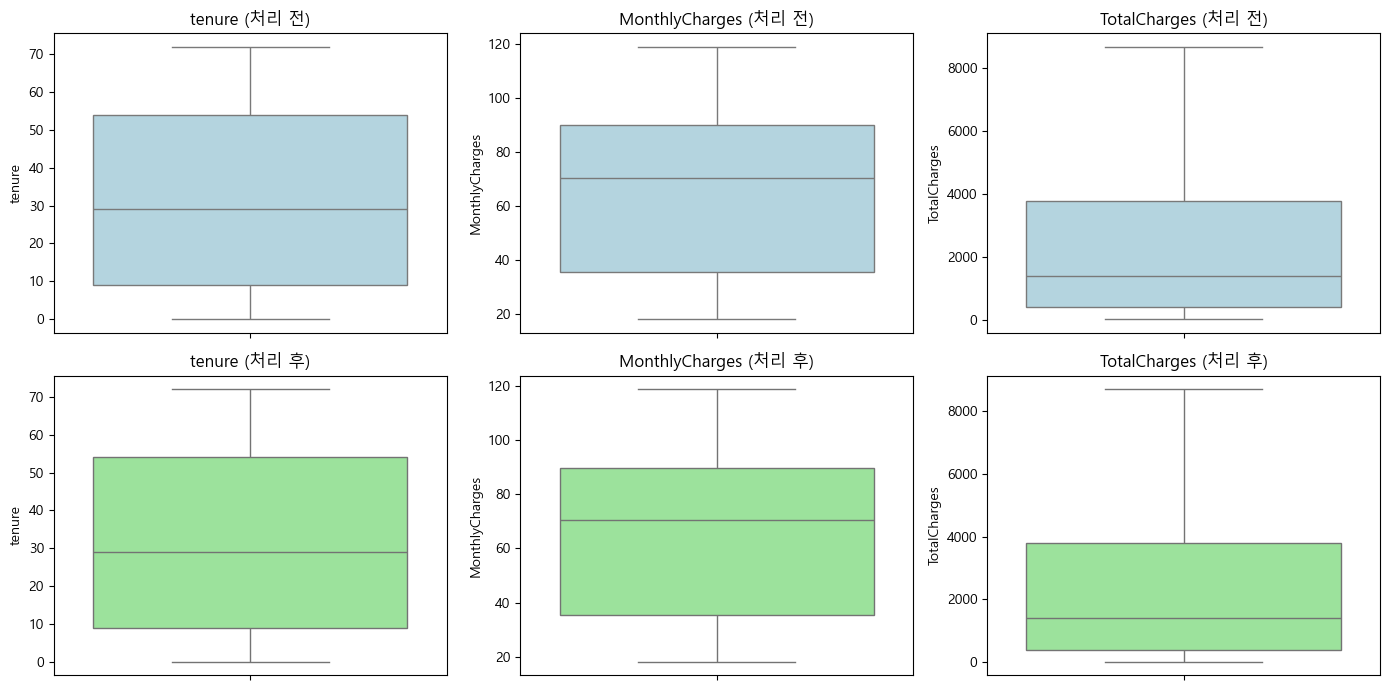

In [35]:
# 시각적 확인: 캡핑 전후 박스플롯
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df_clean[col], ax=axes[0, i], color="lightblue")
    axes[0, i].set_title(f"{col} (처리 전)")

    sns.boxplot(y=df_out[col], ax=axes[1, i], color="lightgreen")
    axes[1, i].set_title(f"{col} (처리 후)")

plt.tight_layout()
plt.show()

## 4) 데이터 분할 및 스케일링/인코딩

**[과제]** 써니는 모델 구축 전 학습/테스트 데이터를 나누려고 합니다. 클래스 불균형이 심한 상황에서 어떤 분할 방법이 적합할지 AI와 상의해서 정하고 나눠 보세요.

In [39]:
df_out.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
missing_pattern     0
dtype: int64

In [49]:
# ============================================================
# 4) train / test 분할 (클래스 불균형 → Stratified Split)
# ============================================================
# 전제: df_out = 결측치 대치 + 이상치 처리 완료 데이터

from sklearn.model_selection import train_test_split
# 인코딩이 아니라 삭제
if "missing_pattern" in df_out.columns:
    df_out = df_out.drop(columns=["missing_pattern"])
# 그다음 X, y 분리 → train/test → 인코딩
y = df_out["Churn"].map({"No": 0, "Yes": 1})
X = df_out.drop(columns=["Churn"])

print("=== 분할 전 전체 클래스 분포 ===")
print(y.value_counts())
print(y.value_counts(normalize=True).mul(100).round(2).to_string())

=== 분할 전 전체 클래스 분포 ===
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.46
1    26.54


In [50]:
# 2) 계층화 분할 (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # train 80% / test 20%
    random_state=42,
    stratify=y            # 클래스 비율 유지
)

print("=== 분할 후 데이터 크기 ===")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

=== 분할 후 데이터 크기 ===
X_train: (5634, 19), X_test: (1409, 19)
y_train: (5634,), y_test: (1409,)


In [51]:
# 3) 분할 후 클래스 분포 확인 (비율이 비슷해야 함)
def show_class_distribution(y_data, name):
    counts = y_data.value_counts().sort_index()
    ratio = y_data.value_counts(normalize=True).sort_index().mul(100).round(2)
    print(f"\n[{name}]")
    print(f"  No(0):  {counts[0]}명 ({ratio[0]}%)")
    print(f"  Yes(1): {counts[1]}명 ({ratio[1]}%)")

show_class_distribution(y, "전체")
show_class_distribution(y_train, "Train")
show_class_distribution(y_test, "Test")


[전체]
  No(0):  5174명 (73.46%)
  Yes(1): 1869명 (26.54%)

[Train]
  No(0):  4139명 (73.46%)
  Yes(1): 1495명 (26.54%)

[Test]
  No(0):  1035명 (73.46%)
  Yes(1): 374명 (26.54%)


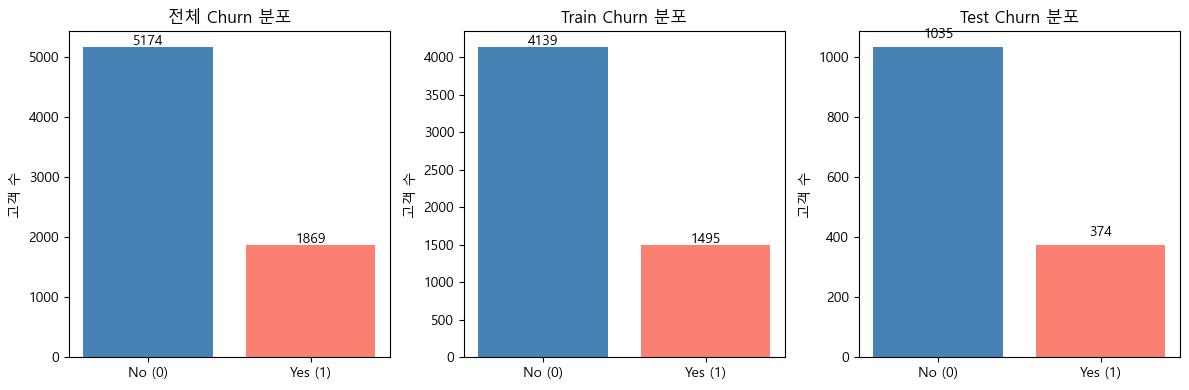

In [52]:
# 4) 시각화로 비교
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ["전체", "Train", "Test"]
data_list = [y, y_train, y_test]

for ax, title, data in zip(axes, titles, data_list):
    counts = data.value_counts().sort_index()
    ax.bar(["No (0)", "Yes (1)"], counts.values, color=["steelblue", "salmon"])
    ax.set_title(f"{title} Churn 분포")
    ax.set_ylabel("고객 수")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, str(v), ha="center")

plt.tight_layout()
plt.show()

**[과제]** 써니는 분할한 학습/테스트 데이터에 적절한 스케일링 및 인코딩을 적용하고자 합니다. AI와 상의하여 수치형 변수와 범주형 변수 각각에 적합한 스케일링 및 인코딩 방식을 정하고 적용해보세요.

In [53]:
# ============================================================
# 4) 범주형 인코딩 (train fit → test transform)
# ============================================================

# 이분형 Yes/No
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
binary_map = {"No": 0, "Yes": 1}

# 순서형
ordinal_maps = {
    "Contract": {"Month-to-month": 0, "One year": 1, "Two year": 2}
}

# One-Hot 대상
onehot_cols = [
    "gender",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaymentMethod",
]

def encode_features(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    # 1) 이분형 매핑
    for col in binary_cols:
        X_train[col] = X_train[col].map(binary_map)
        X_test[col] = X_test[col].map(binary_map)

    # 2) 순서형 매핑
    for col, mapping in ordinal_maps.items():
        X_train[col] = X_train[col].map(mapping)
        X_test[col] = X_test[col].map(mapping)

    # 3) One-Hot (train 기준 컬럼 생성)
    X_train = pd.get_dummies(X_train, columns=onehot_cols, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=onehot_cols, drop_first=True)

    # 4) test에 없는 컬럼 0으로 채우고, train과 컬럼 순서 맞추기
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    return X_train, X_test

# 인코딩 적용
X_train_enc, X_test_enc = encode_features(X_train, X_test)

print("인코딩 전 feature 수:", X_train.shape[1])
print("인코딩 후 feature 수:", X_train_enc.shape[1])
print("\n데이터 타입:")
print(X_train_enc.dtypes.value_counts())
print("\n샘플:")
display(X_train_enc.head(3))

인코딩 전 feature 수: 19
인코딩 후 feature 수: 29

데이터 타입:
bool       20
int64       5
float64     4
Name: count, dtype: int64

샘플:


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0.0,0,0,35.0,0,0,0,49.20,1701.65,True,...,True,False,False,False,True,False,True,False,True,False
3151,0.0,1,1,15.0,1,0,0,75.10,1151.55,True,...,False,False,False,False,False,False,False,False,False,True
4860,0.0,1,1,29.0,0,2,0,40.55,590.35,True,...,False,False,True,False,False,False,False,False,False,True


In [54]:
# ============================================================
# 4) 수치형 스케일링 (train fit → test transform)
# ============================================================
from sklearn.preprocessing import StandardScaler

# 스케일링 대상 (연속형 수치 변수만)
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()

X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()

# train으로 fit, train/test 각각 transform
X_train_scaled[scale_cols] = scaler.fit_transform(X_train_enc[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test_enc[scale_cols])

print("=== 스케일링 전후 비교 (tenure) ===")
print("Train tenure (전):", X_train_enc["tenure"].describe().round(2).to_string())
print("\nTrain tenure (후):", X_train_scaled["tenure"].describe().round(2).to_string())

print("\n=== 최종 데이터 shape ===")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

=== 스케일링 전후 비교 (tenure) ===
Train tenure (전): count    5634.00
mean       32.37
std        24.21
min         0.00
25%         9.00
50%        29.00
75%        54.00
max        72.00

Train tenure (후): count    5634.00
mean        0.00
std         1.00
min        -1.34
25%        -0.97
50%        -0.14
75%         0.89
max         1.64

=== 최종 데이터 shape ===
X_train_scaled: (5634, 29)
X_test_scaled:  (1409, 29)


In [55]:
X_train_scaled.dtypes.value_counts()

bool       20
int64       5
float64     4
Name: count, dtype: int64

## 5) 클래스 불균형 시각화 및 Resampling 적용

**[과제]** 써니는 Churn 여부에 따라 고객들의 데이터가 얼마나 잘 구분되는지 궁금합니다. t-SNE로 학습 데이터를 2차원에 시각화하여 두 클래스가 얼마나 겹쳐 있는지 AI와 함께 코드를 작성하고 분석해보세요.

In [56]:
# ============================================================
# 5) t-SNE — 학습 데이터 Churn별 2차원 시각화
# ============================================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# 학습 데이터만 사용 (과제 조건)
X_tsne_input = X_train_scaled.values   # DataFrame이면 .values
y_tsne = y_train.values                  # 0=유지(No), 1=이탈(Yes)

# t-SNE 적용 (고차원 → 2차원)
tsne = TSNE(
    n_components=2,
    perplexity=30,          # 보통 5~50, 데이터 크기에 따라 조정
    init="random",
    learning_rate="auto",
    random_state=42
)

X_embedded = tsne.fit_transform(X_tsne_input)

print("t-SNE 변환 완료:", X_embedded.shape)

t-SNE 변환 완료: (5634, 2)


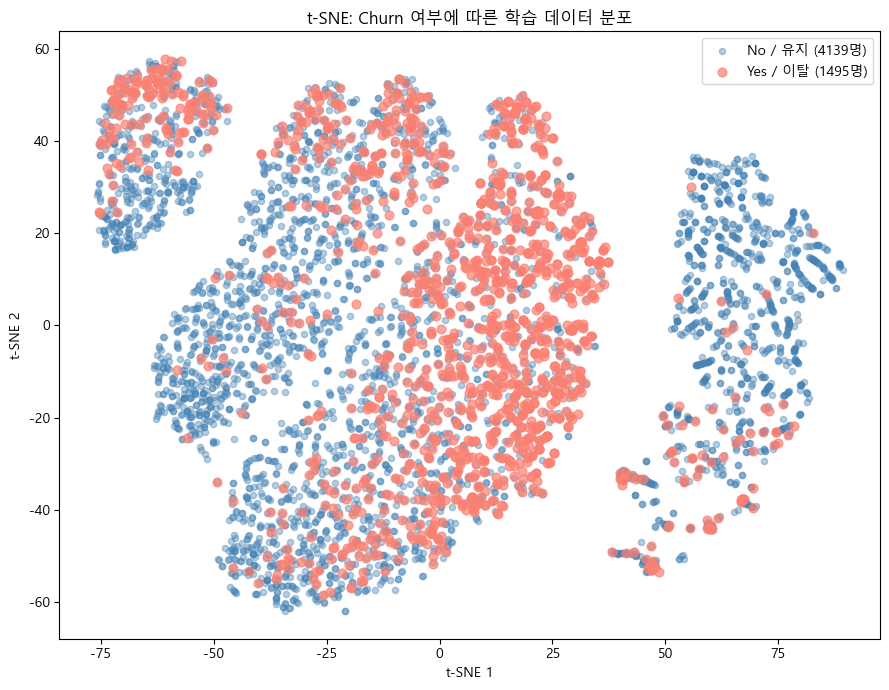

In [57]:
# 시각화
plt.figure(figsize=(9, 7))

# No(0) = 유지 — 다수 클래스
plt.scatter(
    X_embedded[y_tsne == 0, 0],
    X_embedded[y_tsne == 0, 1],
    label=f"No / 유지 ({(y_tsne == 0).sum()}명)",
    alpha=0.4,
    s=20,
    c="steelblue"
)

# Yes(1) = 이탈 — 소수 클래스
plt.scatter(
    X_embedded[y_tsne == 1, 0],
    X_embedded[y_tsne == 1, 1],
    label=f"Yes / 이탈 ({(y_tsne == 1).sum()}명)",
    alpha=0.7,
    s=40,
    c="salmon"
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE: Churn 여부에 따른 학습 데이터 분포")
plt.legend()
plt.tight_layout()
plt.show()

**[과제]** 써니는 클래스 불균형을 완화하기 위해 여러 Resampling 기법(TomekLinks, SMOTE, SMOTE+TomekLinks, ADASYN)을 학습 데이터에 적용해보고 t-SNE로 데이터 분포가 어떻게 변하는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

> Tip: Resampling은 학습 데이터에만 적용하고, 테스트 데이터는 원본 그대로 유지할 것

In [58]:
X_TomekLinks, y_TomekLinks = TomekLinks().fit_resample(X_train_scaled, y_train)

# 적용 전/후 클래스별 개수 비교
compare_TL = pd.DataFrame({
    "적용 전": y_train.value_counts(),
    "적용 후": pd.Series(y_TomekLinks).value_counts()
})
compare_TL["변화"] = compare_TL["적용 후"] - compare_TL["적용 전"]
compare_TL

,적용 전,적용 후,변화
Churn,,,
0,4139,3767,-372
1,1495,1495,0


In [59]:
X_SMOTE, y_SMOTE = SMOTE(random_state=42).fit_resample(X_train_scaled, y_train)

compare_SMOTE = pd.DataFrame({
    "적용 전": y_train.value_counts(),
    "적용 후": pd.Series(y_SMOTE).value_counts()
})
compare_SMOTE["변화"] = compare_SMOTE["적용 후"] - compare_SMOTE["적용 전"]
compare_SMOTE

,적용 전,적용 후,변화
Churn,,,
0,4139,4139,0
1,1495,4139,2644


In [60]:
X_SMOTETomek, y_SMOTETomek = SMOTETomek(random_state=42).fit_resample(X_train_scaled, y_train)

compare_SMOTE_TL = pd.DataFrame({
    "적용 전": y_train.value_counts(),
    "적용 후": pd.Series(y_SMOTETomek).value_counts()
})
compare_SMOTE_TL["변화"] = compare_SMOTE_TL["적용 후"] - compare_SMOTE_TL["적용 전"]
compare_SMOTE_TL

,적용 전,적용 후,변화
Churn,,,
0,4139,3982,-157
1,1495,3982,2487


In [61]:
X_ADASYN, y_ADASYN = ADASYN(random_state=42).fit_resample(X_train_scaled, y_train)

compare_ADA = pd.DataFrame({
    "적용 전": y_train.value_counts(),
    "적용 후": pd.Series(y_ADASYN).value_counts()
})
compare_ADA["변화"] = compare_ADA["적용 후"] - compare_ADA["적용 전"]
compare_ADA

,적용 전,적용 후,변화
Churn,,,
0,4139,4139,0
1,1495,4126,2631


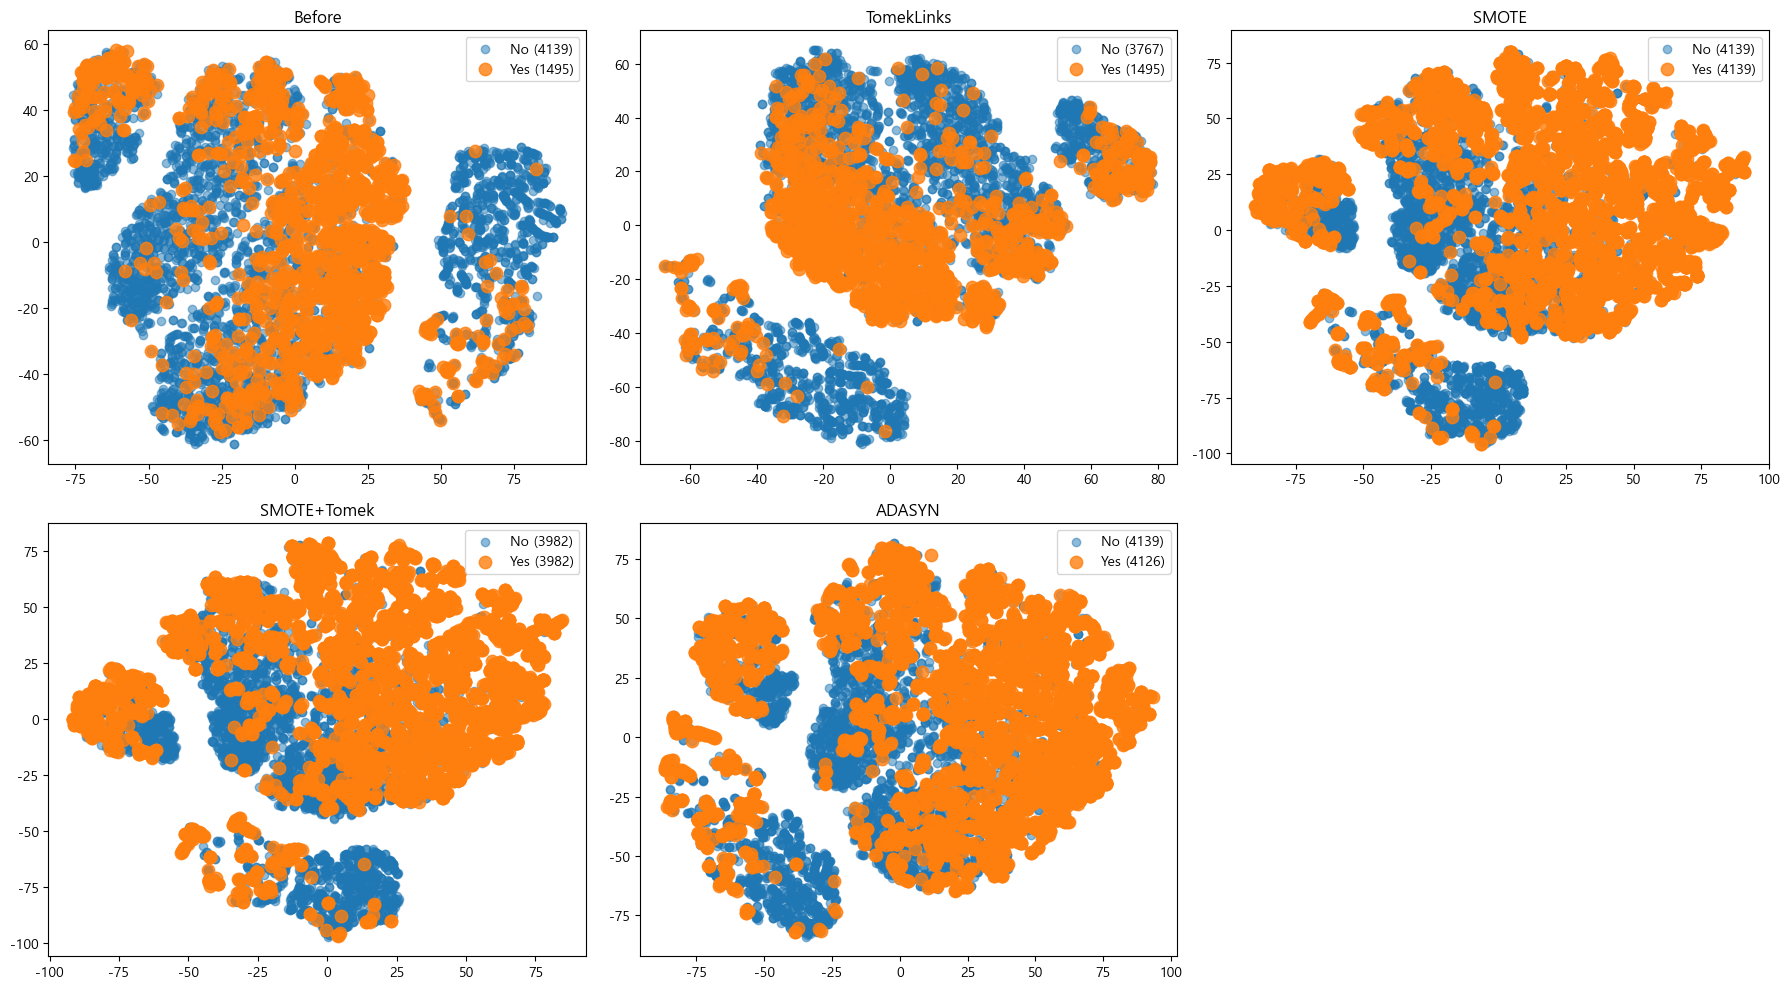

In [62]:
A, B = 0, 1   # 0=No(유지), 1=Yes(이탈)

sampling_datasets = {
    "Before":      (X_train_scaled, y_train),
    "TomekLinks":  (X_TomekLinks, y_TomekLinks),
    "SMOTE":       (X_SMOTE, y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, y_SMOTETomek),
    "ADASYN":      (X_ADASYN, y_ADASYN),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (X_s, Y_s)) in enumerate(sampling_datasets.items()):
    emb = TSNE(
        n_components=2, init="random",
        learning_rate="auto", perplexity=30, random_state=42
    ).fit_transform(X_s)

    Y_s = pd.Series(Y_s)   # numpy로 반환될 수 있어 Series로 통일

    axes[i].scatter(
        emb[Y_s.values == A, 0], emb[Y_s.values == A, 1],
        label=f"No ({(Y_s==A).sum()})", alpha=0.5
    )
    axes[i].scatter(
        emb[Y_s.values == B, 0], emb[Y_s.values == B, 1],
        label=f"Yes ({(Y_s==B).sum()})", alpha=0.8, s=80
    )
    axes[i].set_title(name)
    axes[i].legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()

**[과제]** 써니는 Resampling 기법별로 분류 모델(예: XGBoost)을 학습시켜 성능을 비교하려고 합니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [63]:
sampling_datasets = {
    "Before":      (X_train_scaled, y_train),
    "TomekLinks":  (X_TomekLinks, y_TomekLinks),
    "SMOTE":       (X_SMOTE, y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, y_SMOTETomek),
    "ADASYN":      (X_ADASYN, y_ADASYN),
}

In [64]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

results = []
trained_models = {}   # 나중에 재사용 가능

for name, (X_tr, y_tr) in sampling_datasets.items():
    y_tr = pd.Series(y_tr)   # fit_resample 결과가 numpy일 수 있음

    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    scale_pos_weight = neg / pos   # 학습 데이터 불균형 비율 반영

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    )

    xgb.fit(X_tr, y_tr)
    trained_models[name] = xgb

    print(f"[{name}] 학습 완료 — No:{neg}, Yes:{pos}, scale_pos_weight:{scale_pos_weight:.2f}")

[Before] 학습 완료 — No:4139, Yes:1495, scale_pos_weight:2.77
[TomekLinks] 학습 완료 — No:3767, Yes:1495, scale_pos_weight:2.52
[SMOTE] 학습 완료 — No:4139, Yes:4139, scale_pos_weight:1.00
[SMOTE+Tomek] 학습 완료 — No:3982, Yes:3982, scale_pos_weight:1.00
[ADASYN] 학습 완료 — No:4139, Yes:4126, scale_pos_weight:1.00


In [65]:
results = []

for name, (X_tr, y_tr) in sampling_datasets.items():
    y_tr = pd.Series(y_tr)

    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    scale_pos_weight = neg / pos

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    )
    xgb.fit(X_tr, y_tr)

    # 테스트는 원본 불균형 데이터 (Resampling X)
    pred = xgb.predict(X_test_scaled)

    results.append({
        "Method": name,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred, pos_label=1), 4),
        "Recall": round(recall_score(y_test, pred, pos_label=1), 4),
        "F1-score": round(f1_score(y_test, pred, pos_label=1), 4),
    })

results_df = pd.DataFrame(results)
print("=== Resampling 기법별 XGBoost 성능 비교 ===")
results_df

=== Resampling 기법별 XGBoost 성능 비교 ===


,Method,Accuracy,Precision,Recall,F1-score
0,Before,0.7587,0.5347,0.7005,0.6065
1,TomekLinks,0.7608,0.5366,0.7246,0.6166
2,SMOTE,0.7594,0.5376,0.6684,0.5959
3,SMOTE+Tomek,0.7594,0.5388,0.6497,0.5891
4,ADASYN,0.7509,0.5238,0.6765,0.5904


## 6) SVDD (One-Class SVM) 적용

**[과제]** 써니는 Resampling 방식 대신, 정상(Non-Churn) 데이터만으로 정상 영역을 학습하는 One-Class Learning 접근은 성능이 어떨지 궁금해졌습니다. AI와 함께 One-Class SVM(SVDD)을 정상 데이터로만 학습시키고 Churn 샘플이 그 경계 밖으로 얼마나 잘 걸러지는지 코드를 작성하고 분석해보세요.

> Tip: 정상 데이터로만 학습하고 테스트는 정상/이상 모두 진행

In [66]:
# ============================================================
# 6) SVDD (One-Class SVM) — 정상(Non-Churn) 데이터만으로 학습
# ============================================================
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# 1) 정상 데이터만 추출 (Churn=No, y=0)
X_train_normal = X_train_scaled[y_train == 0]

print(f"학습(정상만): {X_train_normal.shape}")
print(f"테스트: {X_test_scaled.shape} (Yes/이탈: {(y_test == 1).sum()}개)")
print(f"학습 데이터 Yes 비율(참고): {y_train.mean()*100:.1f}%")

학습(정상만): (4139, 29)
테스트: (1409, 29) (Yes/이탈: 374개)
학습 데이터 Yes 비율(참고): 26.5%


In [67]:
# 2) One-Class SVM 학습
# nu: 경계 허용 이상치 비율 상한 (Churn 비율 ~26% 참고)
churn_rate = y_train.mean()   # 약 0.265

oc_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=churn_rate              # 또는 0.265 로 고정
)
oc_svm.fit(X_train_normal)

# 3) 예측 및 라벨 변환
# OneClassSVM: +1 = inlier(정상/유지), -1 = outlier(이상/이탈)
y_pred_raw = oc_svm.predict(X_test_scaled)
y_pred = np.where(y_pred_raw == -1, 1, 0)   # -1 → Yes(1), +1 → No(0)

In [68]:
# 4) 성능 평가 (Yes=1 / 이탈 기준)
print("=== One-Class SVM (SVDD) 성능 ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred, pos_label=1):.4f}")

print("\n혼동행렬:")
print(confusion_matrix(y_test, y_pred))

print("\n", classification_report(
    y_test, y_pred,
    target_names=["No(유지)", "Yes(이탈)"]
))

=== One-Class SVM (SVDD) 성능 ===
Accuracy  : 0.6274
Precision : 0.3145
Recall    : 0.3422
F1-score  : 0.3278

혼동행렬:
[[756 279]
 [246 128]]

               precision    recall  f1-score   support

      No(유지)       0.75      0.73      0.74      1035
     Yes(이탈)       0.31      0.34      0.33       374

    accuracy                           0.63      1409
   macro avg       0.53      0.54      0.54      1409
weighted avg       0.64      0.63      0.63      1409



**[과제]** 써니는 `nu` 값에 따라 SVDD의 경계와 성능이 어떻게 달라지는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

In [74]:
nu_results = []

for nu in [0.05, 0.1, 0.15, 0.2, 0.265, 0.3, 0.35]:
    model = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
    model.fit(X_train_normal)

    pred_raw = model.predict(X_test_scaled)
    pred = np.where(pred_raw == -1, 1, 0)

    nu_results.append({
        "nu": nu,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred, pos_label=1, zero_division=0), 4),
        "Recall": round(recall_score(y_test, pred, pos_label=1, zero_division=0), 4),
        "F1-score": round(f1_score(y_test, pred, pos_label=1, zero_division=0), 4),
    })

nu_df = pd.DataFrame(nu_results)
print("=== nu별 SVDD 성능 ===")
nu_df

=== nu별 SVDD 성능 ===


,nu,Accuracy,Precision,Recall,F1-score
0,0.050,0.7189,0.3854,0.0989,0.1574
1,0.100,0.6948,0.3391,0.1578,0.2153
2,0.150,0.6749,0.3306,0.2193,0.2637
3,0.200,0.6608,0.3365,0.2861,0.3092
4,0.265,0.6281,0.3153,0.3422,0.3282
5,0.300,0.6160,0.3173,0.3877,0.3490
6,0.350,0.6011,0.3303,0.4893,0.3944


## 7) 모델 결과 분석 및 비교

**[과제]** 써니는 지금까지 클래스 불균형 해결을 위해 시도한 Resampling과 One-Class Learning 중, 이 이탈 탐지 문제에는 어떤 접근이 더 적합한지 판단하고자 합니다. AI와 함께 두 접근의 성능을 한 표에 정리하고 어떤 상황에서 어떤 방법이 유리한지 인사이트를 도출해 보세요.

In [76]:
# SVDD 결과를 Resampling 결과표에 합치기
svdd_result = {
    "Method": f"One-Class SVM (nu={churn_rate:.3f})",
    "Approach": "One-Class Learning",
    "Accuracy": round(accuracy_score(y_test, y_pred), 4),   # ← 추가
    "Precision": round(precision_score(y_test, y_pred, pos_label=1), 4),
    "Recall": round(recall_score(y_test, y_pred, pos_label=1), 4),
    "F1-score": round(f1_score(y_test, y_pred, pos_label=1), 4),
}

compare_all = pd.concat([results_df, pd.DataFrame([svdd_result])], ignore_index=True)
compare_all = compare_all.sort_values("F1-score", ascending=False).reset_index(drop=True)
compare_all

,Method,Accuracy,Precision,Recall,F1-score,Approach
0,TomekLinks,0.7608,0.5366,0.7246,0.6166,NaN
1,Before,0.7587,0.5347,0.7005,0.6065,NaN
2,SMOTE,0.7594,0.5376,0.6684,0.5959,NaN
3,ADASYN,0.7509,0.5238,0.6765,0.5904,NaN
4,SMOTE+Tomek,0.7594,0.5388,0.6497,0.5891,NaN
5,One-Class SVM (nu=0.265),0.6274,0.3145,0.3422,0.3278,One-Class Learning
